# Prueba HVSR con hvsrpy

Este cuaderno ejecuta un analisis HVSR tradicional con la biblioteca `hvsrpy` sobre los tres SAC de referencia. La meta es probar un pipeline mantenido para HVSR, no reproducir bit a bit el MATLAB: la seleccion de ventanas, el taper y los estadisticos pueden diferir.

Flujo: leer E/N/Z -> validar sincronizacion -> dividir en ventanas de 32 s -> aplicar Konno-Ohmachi (b=40) -> combinar horizontales por promedio cuadratico -> rechazar ventanas y estimar curva/pico.

Se recomienda ejecutar las celdas en orden. La celda final imprime `f0`/estadisticos, muestra curvas y guarda CSV/PNG/objeto hvsrpy.

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import numpy as np
import matplotlib.pyplot as plt
import obspy
import hvsrpy

print(f"Python package versions: hvsrpy={version('hvsrpy')}, ObsPy={obspy.__version__}, NumPy={np.__version__}")

PROJECT_ROOT = next(
    (parent for start in (Path.cwd().resolve(),) for parent in (start, *start.parents)
     if (parent / "HVMATLAB").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No encuentro HVMATLAB/ desde el directorio de trabajo actual.")

SAC_DIR = PROJECT_ROOT / "HVMATLAB"
SAC_FILES = [
    SAC_DIR / "00P2-2_WA.WAU40..HHE.D.2020.281.sac",  # E
    SAC_DIR / "00P2-2_WA.WAU40..HHN.D.2020.281.sac",  # N
    SAC_DIR / "00P2-2_WA.WAU40..HHZ.D.2020.281.sac",  # Z
]
OUTPUT_DIR = PROJECT_ROOT / "main" / "hvsrpy_test_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_files = [str(path) for path in SAC_FILES if not path.is_file()]
if missing_files:
    raise FileNotFoundError("No existen los archivos SAC: " + ", ".join(missing_files))
print(f"Raiz: {PROJECT_ROOT}")
print(f"Archivos SAC listos: {len(SAC_FILES)}; salida: {OUTPUT_DIR}")

Python package versions: hvsrpy=2.1.0, ObsPy=1.5.1, NumPy=2.4.6
Raiz: /home/orincon/ciudad-perdida-hvsr
Archivos SAC listos: 3; salida: /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs


## 1. Lectura y validacion de componentes

`hvsrpy.read` recibe una lista de mediciones; cada medicion contiene tres archivos en el orden horizontal N, horizontal E y vertical Z para el lector SAC. Despues comprobamos que la biblioteca obtuvo una sola grabacion triaxial, con tres vectores del mismo largo y el mismo intervalo de muestreo.

In [2]:
# hvsrpy SAC reader expects one file for each component, ordered N, E, Z.
SAC_GROUP_NEZ = [str(SAC_FILES[1]), str(SAC_FILES[0]), str(SAC_FILES[2])]
srecords = hvsrpy.read([SAC_GROUP_NEZ], verbose=True)
assert len(srecords) == 1, f"Se esperaba una grabacion, llegaron {len(srecords)}"
record = srecords[0]

print("Tipo de registro:", type(record).__name__)
print("Metadatos:", record.meta)
for component_name in ("ns", "ew", "vt"):
    component = getattr(record, component_name)
    print(component_name, type(component).__name__,
          "public attributes:", [name for name in dir(component) if not name.startswith("_")])

Tipo de registro: SeismicRecording3C
Metadatos: {'file name(s)': ['/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHN.D.2020.281.sac', '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHE.D.2020.281.sac', '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHZ.D.2020.281.sac'], 'deployed degrees from north': 0.0, 'current degrees from north': 0.0}
ns TimeSeries public attributes: ['amplitude', 'butterworth_filter', 'detrend', 'dt_in_seconds', 'fnyq', 'from_timeseries', 'from_trace', 'fs', 'is_similar', 'n_samples', 'split', 'time', 'trim', 'window']
ew TimeSeries public attributes: ['amplitude', 'butterworth_filter', 'detrend', 'dt_in_seconds', 'fnyq', 'from_timeseries', 'from_trace', 'fs', 'is_similar', 'n_samples', 'split', 'time', 'trim', 'window']
vt TimeSeries public attributes: ['amplitude', 'butterworth_filter', 'detrend', 'dt_in_seconds', 'fnyq', 'from_timeseries', 'from_trace', 'fs', 'is_similar', 'n_samples', 'split', 'time', 'trim', 'window'

In [3]:
import inspect

print("Preprocessing settings:", inspect.signature(hvsrpy.HvsrPreProcessingSettings))
print("Traditional processing settings:", inspect.signature(hvsrpy.HvsrTraditionalProcessingSettings))
print("STA/LTA rejection signature:", inspect.signature(hvsrpy.sta_lta_window_rejection))
print("STA/LTA rejection documentation:\n", hvsrpy.sta_lta_window_rejection.__doc__)

Preprocessing settings: (hvsrpy_version='2.1.0', orient_to_degrees_from_north=0.0, filter_corner_frequencies_in_hz=[None, None], window_length_in_seconds=60.0, detrend='linear', ignore_dissimilar_time_step_warning=False, preprocessing_method='hvsr')
Traditional processing settings: (hvsrpy_version='2.1.0', window_type_and_width=['tukey', 0.1], smoothing={'operator': 'konno_and_ohmachi', 'bandwidth': 40, 'center_frequencies_in_hz': array([ 0.1       ,  0.10317219,  0.10644501,  0.10982166,  0.11330541,
        0.11689968,  0.12060796,  0.12443388,  0.12838116,  0.13245366,
        0.13665535,  0.14099032,  0.14546281,  0.15007717,  0.15483791,
        0.15974966,  0.16481723,  0.17004555,  0.17543973,  0.18100501,
        0.18674684,  0.19267081,  0.1987827 ,  0.20508848,  0.21159428,
        0.21830646,  0.22523156,  0.23237634,  0.23974777,  0.24735303,
        0.25519955,  0.26329497,  0.2716472 ,  0.28026437,  0.2891549 ,
        0.29832745,  0.30779097,  0.3175547 ,  0.32762815,  0

## 2. Ventanas, preprocesamiento y ajustes espectrales

`HvsrPreProcessingSettings.window_length_in_seconds=32` corta la grabacion en ventanas de duracion fija. Se quita la tendencia lineal y no se filtra. El procesamiento usa una ventana Tukey con 4 % de ancho total (aprox. 2 % por extremo), Konno-Ohmachi $b=40$, 512 frecuencias logaritmicas entre 0.5 y 30 Hz, y `squared-average`:

$$H(f)=\sqrt{\frac{N(f)^2+E(f)^2}{2}},\qquad HV(f)=\frac{H(f)}{Z(f)}.$$

El taper Tukey es una opcion estandar y no copia literalmente el taper defectuoso del MATLAB. La curva se calcula primero sin rechazo para poder comparar el efecto de `sta_lta_window_rejection`.

In [7]:
preprocessing_settings = hvsrpy.HvsrPreProcessingSettings()
preprocessing_settings.window_length_in_seconds = 32.0
preprocessing_settings.detrend = "linear"
preprocessing_settings.filter_corner_frequencies_in_hz = (None, None)
preprocessing_settings.orient_to_degrees_from_north = 0.0

processing_settings = hvsrpy.HvsrTraditionalProcessingSettings()
processing_settings.window_type_and_width = ("tukey", 0.04)
processing_settings.smoothing = {
    "operator": "konno_and_ohmachi",
    "bandwidth": 40,
    "center_frequencies_in_hz": np.geomspace(0.5, 30.0, 512),
}
processing_settings.method_to_combine_horizontals = "squared_average"
processing_settings.handle_dissimilar_time_steps_by = "frequency_domain_resampling"

preprocessed_records = hvsrpy.preprocess(srecords, preprocessing_settings)
assert len(preprocessed_records) > 0
assert all(record.ns.n_samples == record.ew.n_samples == record.vt.n_samples
           for record in preprocessed_records)
assert all(np.isclose(record.ns.dt_in_seconds, record.ew.dt_in_seconds)
           and np.isclose(record.ns.dt_in_seconds, record.vt.dt_in_seconds)
           for record in preprocessed_records)

print("Preprocessing settings:")
preprocessing_settings.psummary()
print("Processing settings:")
processing_settings.psummary()
first_window = preprocessed_records[0]
window_duration_s = (first_window.ns.n_samples - 1) * first_window.ns.dt_in_seconds
print(f"Ventanas producidas: {len(preprocessed_records)}")
print(f"Muestras en la primera ventana: {first_window.ns.n_samples}")
print(f"Duracion entre primera y ultima muestra: {window_duration_s:.3f} s")
assert np.isclose(window_duration_s, 32.0)

Preprocessing settings:
hvsrpy_version                           : 2.1.0
orient_to_degrees_from_north             : 0.0
filter_corner_frequencies_in_hz          : (None, None)
window_length_in_seconds                 : 32.0
detrend                                  : linear
preprocessing_method                     : hvsr
Processing settings:
hvsrpy_version                           : 2.1.0
window_type_and_width                    : ('tukey', 0.04)
smoothing                                :
     operator                            : konno_and_ohmachi
     bandwidth                           : 40
     center_frequencies_in_hz            : [0.5, 0.504022300640 ... 0587936160523, 30.0]
fft_settings                             : None
handle_dissimilar_time_steps_by          : frequency_domain_resampling
processing_method                        : traditional
method_to_combine_horizontals            : squared_average
Ventanas producidas: 880
Muestras en la primera ventana: 3201
Duracion entre 

## 3. HVSR tradicional antes del rechazo

`hvsrpy.process` calcula una curva H/V por ventana, suaviza las amplitudes y resume los resultados en un objeto `HvsrTraditional`. Primero conservamos la salida sin rechazos para luego aislar el efecto del filtro STA/LTA.

Tipo HVSR: HvsrTraditional
Frecuencias: 512 (0.5-30 Hz)
Curvas por ventana: (880, 512)
Pico de la media de curvas crudas: 10.0896365139296 Hz


,Exponentitated Lognormal Median (units),Lognormal Standard Deviation (log units),-1 Lognormal Standard Deviation (units),+1 Lognormal Standard Deviation (units)
"Resonant Site Frequency, fn (Hz)",9.463,0.354,6.644,13.476
"Resonant Site Period, Tn (s)",0.106,0.354,0.151,0.074
"Resonance Amplitude, An",6.001,0.162,5.104,7.056


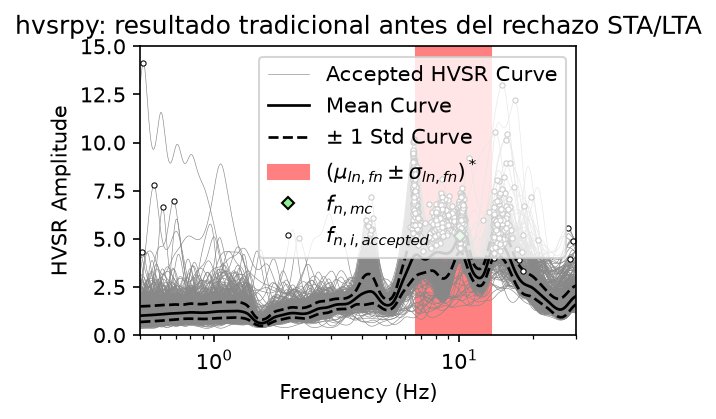

In [8]:
hvsr_raw = hvsrpy.process(preprocessed_records, processing_settings)
frequency_hz = np.asarray(hvsr_raw.frequency)
raw_hv_curves = np.asarray(hvsr_raw.amplitude)
assert raw_hv_curves.shape == (len(preprocessed_records), frequency_hz.size)
assert np.all(np.isfinite(frequency_hz)) and np.all(np.diff(frequency_hz) > 0)

print("Tipo HVSR:", type(hvsr_raw).__name__)
print("Frecuencias:", frequency_hz.size, f"({frequency_hz[0]:.3g}-{frequency_hz[-1]:.3g} Hz)")
print("Curvas por ventana:", raw_hv_curves.shape)
print("Pico de la media de curvas crudas:", frequency_hz[np.argmax(np.mean(raw_hv_curves, axis=0))], "Hz")
hvsrpy.summarize_hvsr_statistics(hvsr_raw)

fig, ax = hvsrpy.plot_single_panel_hvsr_curves(hvsr_raw)
ax.set_xlim(0.5, 30.0)
ax.set_title("hvsrpy: resultado tradicional antes del rechazo STA/LTA")
plt.show()

## 4. Rechazo STA/LTA de hvsrpy

Ahora se ejecuta el rechazo temporal con los mismos valores de referencia: STA=2 s, LTA=25 s, razon admisible entre 0.2 y 2.0. `hvsrpy` evalua las componentes indicadas y actualiza la mascara de ventanas validas del objeto HVSR. Esto permite comparar directamente el numero de ventanas conservadas, pero no garantiza los mismos indices del MATLAB: el original calcula la magnitud vectorial y su propio trigger.

Ventanas antes del rechazo: 880
Ventanas aceptadas por STA/LTA hvsrpy: 679
Ventanas rechazadas: 201


,Exponentitated Lognormal Median (units),Lognormal Standard Deviation (log units),-1 Lognormal Standard Deviation (units),+1 Lognormal Standard Deviation (units)
"Resonant Site Frequency, fn (Hz)",9.414,0.282,7.098,12.486
"Resonant Site Period, Tn (s)",0.106,0.282,0.141,0.080
"Resonance Amplitude, An",5.954,0.146,5.144,6.890


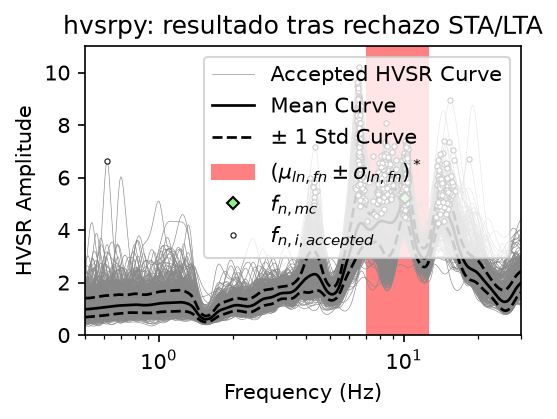

In [9]:
records_after_sta_lta = hvsrpy.sta_lta_window_rejection(
    preprocessed_records,
    sta_seconds=2.0,
    lta_seconds=25.0,
    min_sta_lta_ratio=0.2,
    max_sta_lta_ratio=2.0,
    components=("ns", "ew", "vt"),
    hvsr=hvsr_raw,
)
valid_window_mask = np.asarray(hvsr_raw.valid_window_boolean_mask, dtype=bool)
assert valid_window_mask.size == len(preprocessed_records)
assert len(records_after_sta_lta) == int(valid_window_mask.sum())
print(f"Ventanas antes del rechazo: {len(preprocessed_records)}")
print(f"Ventanas aceptadas por STA/LTA hvsrpy: {len(records_after_sta_lta)}")
print(f"Ventanas rechazadas: {len(preprocessed_records) - len(records_after_sta_lta)}")

hvsrpy.summarize_hvsr_statistics(hvsr_raw)
fig, ax = hvsrpy.plot_single_panel_hvsr_curves(hvsr_raw)
ax.set_xlim(0.5, 30.0)
ax.set_title("hvsrpy: resultado tras rechazo STA/LTA")
plt.show()

## 5. Comparacion de rechazo

Ademas del STA/LTA temporal, `hvsrpy` implementa el rechazo en dominio de frecuencia de Cox et al. (2020). Se ejecuta sobre un objeto independiente para no mezclar las mascaras. El numero de ventanas retenidas depende del criterio; ninguno debe confundirse con el selector MATLAB, que trabaja sobre una magnitud vectorial en el tiempo.

In [10]:
hvsr_fdr = hvsrpy.process(preprocessed_records, processing_settings)
fdr_iterations = hvsrpy.frequency_domain_window_rejection(
    hvsr_fdr,
    max_iterations=10,
    search_range_in_hz=(0.5, 30.0),
)

def get_valid_curve_mask(hvsr_object):
    for attribute_name in ("valid_window_boolean_mask", "valid_curve_boolean_mask"):
        if hasattr(hvsr_object, attribute_name):
            return np.asarray(getattr(hvsr_object, attribute_name), dtype=bool)
    raise AttributeError("No encuentro la mascara de curvas validas en el objeto hvsrpy.")

fdr_valid_mask = get_valid_curve_mask(hvsr_fdr)
assert fdr_valid_mask.size == len(preprocessed_records)
assert np.isfinite(hvsr_raw.mean_fn_frequency(distribution="lognormal"))
assert 0.5 <= hvsr_raw.mean_fn_frequency(distribution="lognormal") <= 30.0
assert np.all(np.isfinite(hvsr_raw.mean_curve(distribution="lognormal")))

print(f"STA/LTA: {int(valid_window_mask.sum())}/{len(preprocessed_records)} ventanas validas")
print(f"Rechazo en frecuencia: {int(fdr_valid_mask.sum())}/{len(preprocessed_records)} validas; iteraciones={fdr_iterations}")
print(f"Pico de la curva media (STA/LTA): {hvsr_raw.mean_curve_peak(distribution='lognormal')}")
print(f"Frecuencia media de picos por ventana (STA/LTA): {hvsr_raw.mean_fn_frequency(distribution='lognormal'):.4f} Hz")
print(f"Curva media lognormal (max amplitude): {np.max(hvsr_raw.mean_curve(distribution='lognormal')):.4f}")

STA/LTA: 679/880 ventanas validas
Rechazo en frecuencia: 840/880 validas; iteraciones=5
Pico de la curva media (STA/LTA): (np.float64(10.0896365139296), np.float64(5.239032430664514))
Frecuencia media de picos por ventana (STA/LTA): 9.4138 Hz
Curva media lognormal (max amplitude): 5.2390


## 6. Comparacion con la curva previa y guardado

Se comparan en la misma malla logaritmica tres resultados `hvsrpy`: todas las ventanas, mascara STA/LTA y rechazo frecuencial Cox. Si existe `outputs_hvsr/hv_curve.csv`, tambien se interpola esa curva de referencia sobre la malla hvsrpy. Las diferencias son diagnosticas: cambian la seleccion, la distribucion estadistica, taper y centros de suavizado, por lo que no se espera igualdad punto a punto.

Comparacion con la curva Python previa: {'median_log10_hvsrpy_over_reference': 0.017600025074540997, 'median_absolute_log10_ratio': 0.01909780074906836, 'reference_f0_hz': 10.009765625}


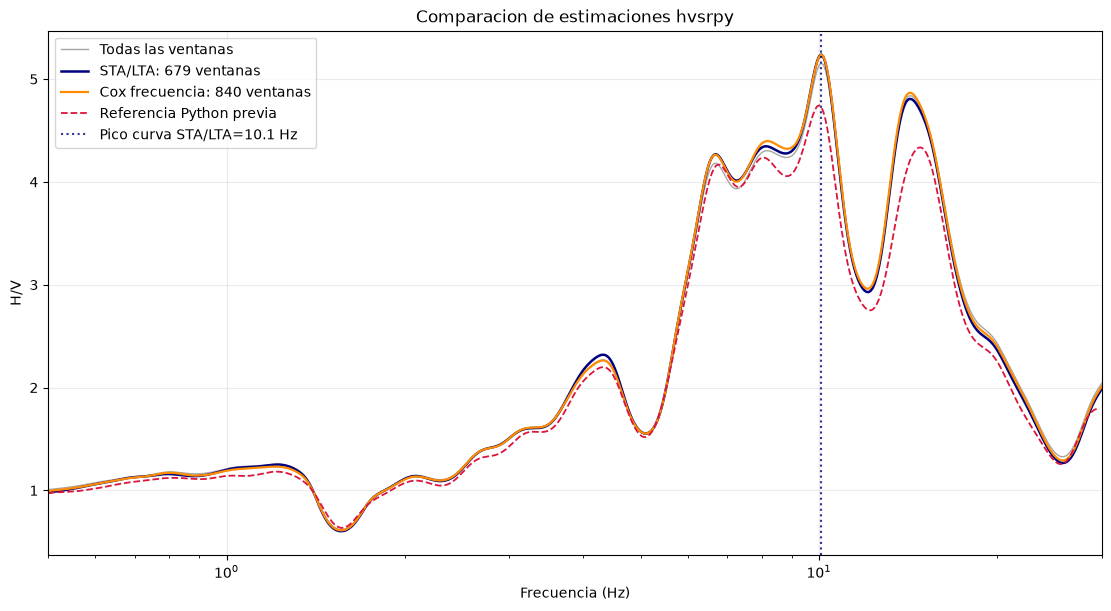

Resultados escritos en:
 - /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/hvsrpy_curves.csv
 - /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/hvsrpy_summary.json
 - /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/hvsrpy_comparison.png
 - /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/hvsrpy_sta_lta_object.csv


In [11]:
mean_all_windows = 10.0 ** np.mean(np.log10(np.maximum(raw_hv_curves, np.finfo(float).tiny)), axis=0)
mean_sta_lta = hvsr_raw.mean_curve(distribution="lognormal")
mean_frequency_rejection = hvsr_fdr.mean_curve(distribution="lognormal")
f0_curve_sta_lta, a0_curve_sta_lta = hvsr_raw.mean_curve_peak(distribution="lognormal")
f0_curve_fdr, a0_curve_fdr = hvsr_fdr.mean_curve_peak(distribution="lognormal")
f0_windows_sta_lta = hvsr_raw.mean_fn_frequency(distribution="lognormal")

hvsrpy_curves_path = OUTPUT_DIR / "hvsrpy_curves.csv"
np.savetxt(
    hvsrpy_curves_path,
    np.column_stack((frequency_hz, mean_all_windows, mean_sta_lta, mean_frequency_rejection)),
    delimiter=",",
    header="frequency_hz,mean_all_windows,mean_after_sta_lta,mean_after_frequency_rejection",
    comments="",
)

reference_path = PROJECT_ROOT / "main" / "02_analysis_hv" / "outputs_hvsr" / "hv_curve.csv"
reference_comparison = None
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
ax.plot(frequency_hz, mean_all_windows, color="0.65", lw=1.0, label="Todas las ventanas")
ax.plot(frequency_hz, mean_sta_lta, color="navy", lw=1.8, label=f"STA/LTA: {valid_window_mask.sum()} ventanas")
ax.plot(frequency_hz, mean_frequency_rejection, color="darkorange", lw=1.6,
        label=f"Cox frecuencia: {fdr_valid_mask.sum()} ventanas")

if reference_path.is_file():
    reference_curve = np.genfromtxt(reference_path, delimiter=",", names=True)
    common_band = ((frequency_hz >= reference_curve["frequency_hz"].min()) &
                   (frequency_hz <= reference_curve["frequency_hz"].max()))
    reference_interp = np.interp(frequency_hz[common_band], reference_curve["frequency_hz"],
                                 reference_curve["HV_geometric_mean"])
    ax.plot(frequency_hz[common_band], reference_interp, color="crimson", ls="--", lw=1.3,
            label="Referencia Python previa")
    log_ratio = np.log10(np.maximum(mean_sta_lta[common_band], np.finfo(float).tiny) /
                         np.maximum(reference_interp, np.finfo(float).tiny))
    reference_comparison = {
        "median_log10_hvsrpy_over_reference": float(np.median(log_ratio)),
        "median_absolute_log10_ratio": float(np.median(np.abs(log_ratio))),
        "reference_f0_hz": float(reference_curve["frequency_hz"][np.argmax(reference_curve["HV_geometric_mean"])]),
    }
    print("Comparacion con la curva Python previa:", reference_comparison)
else:
    print("No existe outputs_hvsr/hv_curve.csv; se omite la comparacion con la referencia previa.")

ax.axvline(f0_curve_sta_lta, color="navy", ls=":", alpha=0.8,
           label=f"Pico curva STA/LTA={f0_curve_sta_lta:.3g} Hz")
ax.set_xscale("log")
ax.set_xlim(0.5, 30.0)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("H/V")
ax.set_title("Comparacion de estimaciones hvsrpy")
ax.grid(alpha=0.25)
ax.legend()
comparison_figure_path = OUTPUT_DIR / "hvsrpy_comparison.png"
fig.savefig(comparison_figure_path, dpi=180)
plt.show()

hvsrpy_summary = {
    "package_version": version("hvsrpy"),
    "input_sac_files": [str(path) for path in SAC_FILES],
    "sampling_rate_hz": float(record.ns.fs),
    "dt_seconds": float(record.ns.dt_in_seconds),
    "window_length_seconds": 32.0,
    "number_windows_before_rejection": int(len(preprocessed_records)),
    "number_windows_after_sta_lta": int(valid_window_mask.sum()),
    "number_windows_after_frequency_rejection": int(fdr_valid_mask.sum()),
    "frequency_rejection_iterations": int(fdr_iterations),
    "STA_seconds": 2.0, "LTA_seconds": 25.0,
    "STA_LTA_min": 0.2, "STA_LTA_max": 2.0,
    "smoothing_operator": "konno_and_ohmachi", "smoothing_bandwidth": 40,
    "horizontal_method": "squared_average",
    "f0_peak_mean_curve_sta_lta_hz": float(f0_curve_sta_lta),
    "A0_peak_mean_curve_sta_lta": float(a0_curve_sta_lta),
    "fn_mean_of_window_peaks_sta_lta_hz": float(f0_windows_sta_lta),
    "f0_peak_mean_curve_frequency_rejection_hz": float(f0_curve_fdr),
    "A0_peak_mean_curve_frequency_rejection": float(a0_curve_fdr),
    "reference_curve_comparison": reference_comparison,
}
summary_path = OUTPUT_DIR / "hvsrpy_summary.json"
summary_path.write_text(json.dumps(hvsrpy_summary, indent=2, ensure_ascii=False), encoding="utf-8")
hvsrpy.write_hvsr_object_to_file(hvsr_raw, str(OUTPUT_DIR / "hvsrpy_sta_lta_object.csv"))
print("Resultados escritos en:")
for output_path in (hvsrpy_curves_path, summary_path, comparison_figure_path,
                    OUTPUT_DIR / "hvsrpy_sta_lta_object.csv"):
    print(" -", output_path)

## 5. Criterios SESAME implementados por hvsrpy

`hvsrpy` incorpora sus funciones de confiabilidad y claridad SESAME. Se aplican a la curva posterior al rechazo STA/LTA, con el rango de busqueda 0.5-30 Hz. Son los criterios integrados por la version del paquete; no se deben confundir con la implementacion MATLAB anterior ni tomar como interpretacion geologica automatica.

In [12]:
from hvsrpy.sesame import reliability, clarity

sta_mean_curve = hvsr_raw.mean_curve(distribution="lognormal")
sta_std_curve = hvsr_raw.std_curve(distribution="lognormal")
sta_fn_std_normal = hvsr_raw.std_fn_frequency(distribution="normal")

reliability_result = reliability(
    windowlength=32.0,
    passing_window_count=int(valid_window_mask.sum()),
    frequency=frequency_hz,
    mean_curve=sta_mean_curve,
    std_curve=sta_std_curve,
    search_range_in_hz=(0.5, 30.0),
    verbose=1,
)
clarity_result = clarity(
    frequency=frequency_hz,
    mean_curve=sta_mean_curve,
    std_curve=sta_std_curve,
    fn_std=sta_fn_std_normal,
    search_range_in_hz=(0.5, 30.0),
    verbose=1,
)
print("Resultado reliability:", reliability_result)
print("Resultado clarity:", clarity_result)

Considering only frequencies between 0.500 and 30.000 Hz.
Assessing SESAME (2004) reliability criteria ... 
  Criteria i): Pass
  Criteria ii): Pass
  Criteria iii): Pass
  The chosen peak PASSES the peak reliability criteria, with 3 of 3.
Assessing SESAME (2004) clarity criteria ... 
Considering only frequencies between 0.500 and 30.000 Hz.
  Criteria i): Pass
  Criteria ii): Pass
  Criteria iii): Pass
  Criteria iv): Fail
  Criteria v): Fail
  Criteria vi): Pass
  The chosen peak FAILS the peak clarity criteria, with 4 of 6.
Resultado reliability: [1. 1. 1.]
Resultado clarity: [1. 1. 1. 0. 0. 1.]


### Lectura del resultado de calidad

En este registro la confiabilidad SESAME integrada en `hvsrpy` pasa 3/3, mientras que la claridad pasa 4/6 (falla iv y v). Esto significa que el pico elegido cumple las pruebas de confiabilidad evaluadas, pero su forma no cumple todos los requisitos de claridad. No equivale a validar una geologia concreta: revisa la curva, la dispersion de ventanas y el contexto geologico antes de reportar $f_0$.

In [13]:
hvsrpy_summary["sesame_reliability"] = [int(value) for value in reliability_result]
hvsrpy_summary["sesame_reliability_passed"] = bool(np.all(reliability_result))
hvsrpy_summary["sesame_clarity"] = [int(value) for value in clarity_result]
hvsrpy_summary["sesame_clarity_passed"] = bool(np.all(clarity_result))
hvsrpy_summary["taper"] = {"type": "tukey", "total_width_fraction": 0.04}
hvsrpy_summary["reference_curve_comparison"] = reference_comparison

with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(hvsrpy_summary, handle, indent=2, ensure_ascii=False)

window_quality_path = OUTPUT_DIR / "window_sta_lta_mask.csv"
np.savetxt(
    window_quality_path,
    np.column_stack((np.arange(valid_window_mask.size), valid_window_mask.astype(int))),
    delimiter=",",
    fmt=["%d", "%d"],
    header="window_index,accepted_by_sta_lta",
    comments="",
)
print("Resumen actualizado con SESAME:", summary_path)
print("Mascara STA/LTA guardada:", window_quality_path)
print("Confiabilidad pasa:", hvsrpy_summary["sesame_reliability_passed"])
print("Claridad pasa:", hvsrpy_summary["sesame_clarity_passed"])

Resumen actualizado con SESAME: /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/hvsrpy_summary.json
Mascara STA/LTA guardada: /home/orincon/ciudad-perdida-hvsr/main/hvsrpy_test_outputs/window_sta_lta_mask.csv
Confiabilidad pasa: True
Claridad pasa: False


## 7. Interpretacion de esta ejecucion

Con `hvsrpy 2.1.0` y los SAC suministrados se obtuvieron **880 ventanas** de 32 s. El filtro STA/LTA con 2/25 s y limites 0.2-2.0 retuvo **679**; el rechazo frecuencial de Cox retuvo **840** (5 iteraciones). No son selectores equivalentes: el primero es temporal y por componente; el segundo evalua consistencia espectral.

Despues del STA/LTA, el maximo de la curva media es aproximadamente **10.09 Hz** con **H/V=5.24**, mientras que la media lognormal de los picos individuales es **9.414 Hz**. Son estadisticos distintos: el primero localiza el maximo de una curva agregada; el segundo resume las frecuencias pico de cada ventana.

La curva hvsrpy y la curva Python previa difieren una mediana de **0.0191 log10** en valor absoluto, alrededor de **4.5 %** multiplicativo, pero fueron construidas con mascaras y algoritmos diferentes. La proximidad es una comprobacion de consistencia, no una prueba de equivalencia. En SESAME, confiabilidad pasa 3/3 y claridad 4/6; por tanto, el pico no cumple todos los criterios de claridad.

Para publicaciones, cita el paquete y sus fundamentos: Vantassel (2025), *hvsrpy*, *Seismological Research Letters*, 96(4), 2671-2682, [doi:10.1785/0220240395](https://doi.org/10.1785/0220240395); y las referencias SESAME/Cox que correspondan al algoritmo utilizado.